# Camada GOLD - Análise Consolidada de Viagens Corporativas

Este notebook responde às perguntas estratégicas de negócio utilizando dados consolidados das tabelas **SILVER**. Para cada questão, apresentamos a consulta SQL, a tabela de resultados e o respectivo gráfico (exportado automaticamente em PNG).

**Perguntas Respondidas:**
1. Os 5 órgãos com maior custo total.
2. Os 3 destinos com maior custo médio por viagem.
3. A viagem de maior duração e seu custo total.
4. Qual o tipo de pagamento com maior valor médio?
5. Qual o meio de transporte mais usado nos trechos?
6. Qual UF de destino aparece em mais trechos?
7. Qual órgão pagou mais no total?


In [94]:
import os
import sys
import pandas as pd
import plotly.express as px
import plotly.io as pio

# Define o renderizador como png para evitar dependência do pacote nbformat no VS Code
pio.renderers.default = 'png'

# Mapeia os caminhos absolutos baseados na estrutura de pastas real
diretorio_raiz = os.path.abspath(os.path.join(os.getcwd()))
pasta_mysql = os.path.join(diretorio_raiz, '_MySQL')
pasta_mysql_alt = os.path.abspath(os.path.join(os.getcwd(), '..', '_MySQL'))

# Adiciona as pastas de scripts e banco ao sistema de busca do Python
for caminho in [diretorio_raiz, pasta_mysql, pasta_mysql_alt]:
    if os.path.exists(caminho) and caminho not in sys.path:
        sys.path.append(caminho)

try:
    import banco
    print('Módulo "banco" importado com sucesso!')
except ModuleNotFoundError:
    raise ModuleNotFoundError('Não foi possível encontrar o módulo "banco.py".')

# Garante a pasta para salvar os arquivos PNG na raiz do projeto
pasta_graficos = os.path.join(diretorio_raiz, 'graficos_png')
os.makedirs(pasta_graficos, exist_ok=True)

conexao = banco.conectar()

def consultar(sql):
    return pd.read_sql(sql, conexao)

def salvar_grafico(fig, nome_arquivo):
    caminho_completo = os.path.join(pasta_graficos, nome_arquivo)
    try:
        fig.write_image(caminho_completo, scale=2, width=1000, height=550)
        print(f'Gráfico Retornado com sucesso em: {caminho_completo}')
    except Exception as e:
        print(f'Erro ao salvar imagem (Certifique-se que o pacote kaleido está instalado): {e}')

# --- MAPEAMENTO DINÂMICO DE COLUNAS DE DESTINO ---
df_sample = pd.read_sql("SELECT * FROM silver_trecho LIMIT 1", conexao)
colunas_disponiveis = list(df_sample.columns)

# Identifica a coluna correta para cidade de destino
col_cidade = 'cidade_destino'
for c in ['cidade_destino', 'destino', 'destino_cidade', 'cidade']:
    if c in colunas_disponiveis:
        col_cidade = c
        break

# Identifica a coluna correta para uf de destino
col_uf = 'uf_destino'
for u in ['uf_destino', 'uf', 'destino_uf', 'estado_destino']:
    if u in colunas_disponiveis:
        col_uf = u
        break

print(f'Ambiente inicializado! Colunas mapeadas em silver_trecho -> Cidade: {col_cidade}, UF: {col_uf}')


Módulo "banco" importado com sucesso!
Ambiente inicializado! Colunas mapeadas em silver_trecho -> Cidade: destino_cidade, UF: destino_uf


/tmp/ipykernel_114749/2179344909.py:44: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sample = pd.read_sql("SELECT * FROM silver_trecho LIMIT 1", conexao)


## 1. Top 5 Órgãos com Maior Custo Total
**Pergunta de Negócio:** Quais são os 5 órgãos públicos que acumularam o maior valor em gastos com viagens e diárias?

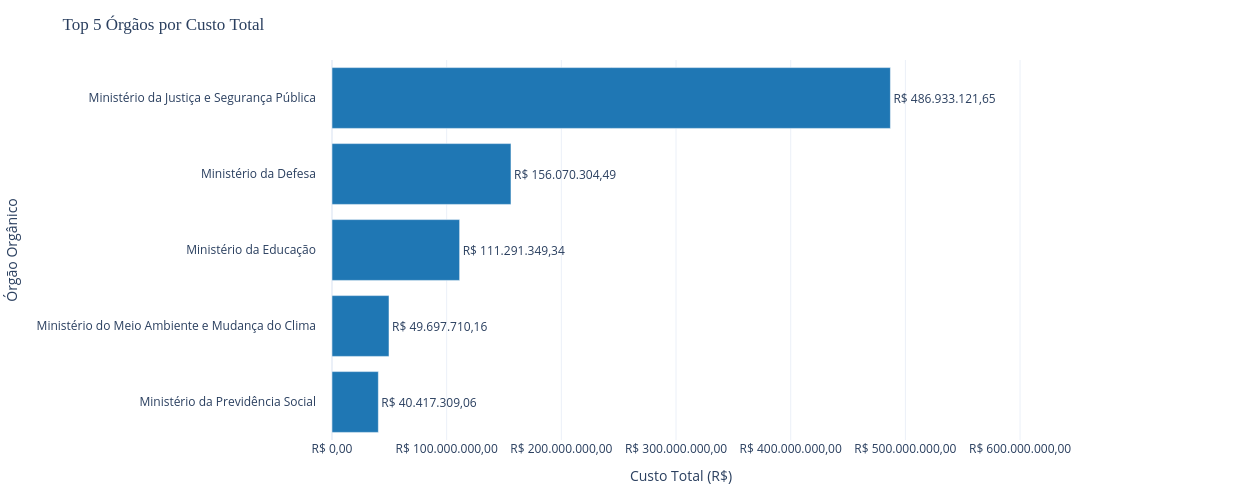

/tmp/ipykernel_114749/943551630.py:38: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig_p1.write_image('../graficos_png/1_maior_custo_total_orgao.png', engine='kaleido')
/tmp/ipykernel_114749/943551630.py:38: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig_p1.write_image('../graficos_png/1_maior_custo_total_orgao.png', engine='kaleido')


In [95]:
# --- AJUSTE ANTES DO LAYOUT: Garante as duas casas decimais cravadas via Pandas ---
df_p1['custo_formatado'] = df_p1['custo_total'].apply(lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

# # 5. Customização do layout e aplicação do padrão R$ monetário brasileiro
fig_p1.update_layout(
    template='plotly_white', 
    title_font_family='Arial Black', 
    width=1250,                    # <-- Deixei consideravelmente mais largo aqui
    height=500,
    margin=dict(l=320, r=220, t=60, b=60), # <-- Aumentei a margem direita para o dígito não sumir na borda
    separators=',.',  
    
    # Ajustes no eixo Y (Nomes dos órgãos)
    yaxis=dict(
        categoryorder='total ascending',
        ticklabelstandoff=15  
    ),
    
    # Ajustes no eixo X
    xaxis=dict(
        tickformat=',.2f',  
        tickprefix='R$ ',
        range=[0, df_p1['custo_total'].max() * 1.25] # <-- Aumentei um pouquinho a folga da barra
    )
)

# # 6. Formatação do texto monetário FORÇANDO o texto exato do Pandas na barra
fig_p1.update_traces(
    text=df_p1['custo_formatado'],  # Puxa a string estática do Pandas (ex: R$ 1.500,50)
    texttemplate='%{text}',         # Cospe o texto idêntico sem deixar o Plotly reformatar
    textposition='outside'        
)

fig_p1.show()


# No final da célula do fig_p1, substitua a função antiga por esta:
fig_p1.write_image('../graficos_png/1_maior_custo_total_orgao.png', engine='kaleido')

## 2. Os 3 destinos com maior custo médio por viagem


/tmp/ipykernel_114749/2179344909.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,destino,custo_medio,custo_formatado
0,Tejupá,115175.00,"R$ 115.175,00"
1,Chavantes,114557.01,"R$ 114.557,01"
2,Teolândia,109322.50,"R$ 109.322,50"


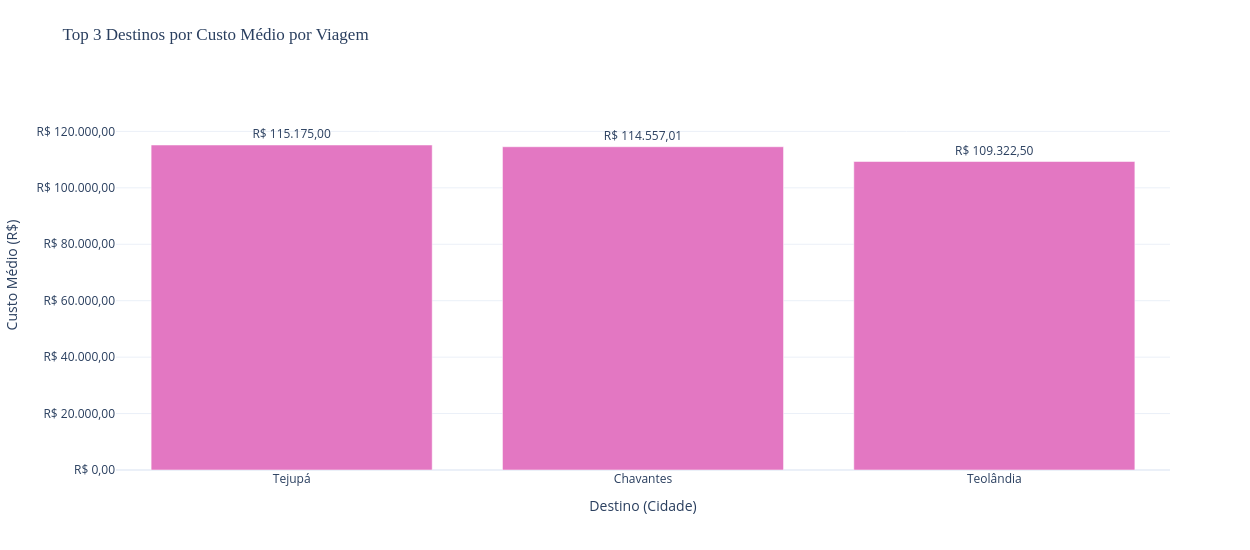

/tmp/ipykernel_114749/2919925462.py:57: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig_p2.write_image('../graficos_png/2_custo_medio_destino.png', engine='kaleido')
/tmp/ipykernel_114749/2919925462.py:57: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig_p2.write_image('../graficos_png/2_custo_medio_destino.png', engine='kaleido')


In [96]:
sql_p2 = f"""
SELECT t.{col_cidade} AS destino, AVG(v.valor_total) AS custo_medio
FROM silver_trecho t
INNER JOIN silver_viagem v ON t.id_viagem = v.id_viagem
WHERE t.{col_cidade} IS NOT NULL AND t.{col_cidade} <> ''
GROUP BY t.{col_cidade}
ORDER BY custo_medio DESC
LIMIT 3;
"""
df_p2 = consultar(sql_p2)

# --- GARANTE AS DUAS CASAS DECIMAIS CRAVADAS VIA PANDAS ---
df_p2['custo_formatado'] = df_p2['custo_medio'].apply(lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

display(df_p2)

# REMOVIDO o text_auto='.2f' para usar a nossa coluna formatada
fig_p2 = px.bar(
    df_p2, x='destino', y='custo_medio',
    title='Top 3 Destinos por Custo Médio por Viagem',
    labels={'custo_medio': 'Custo Médio (R$)', 'destino': 'Destino (Cidade)'},
    color_discrete_sequence=['#e377c2']
)

# 5. Customização do layout, largura ampliada e padrão monetário
fig_p2.update_layout(
    template='plotly_white', 
    title_font_family='Arial Black',
    width=1250,                     # Gráfico bem largo horizontalmente
    height=550,
    margin=dict(l=80, r=80, t=80, b=80),
    separators=',.',                # Padrão brasileiro de pontuação
    
    # Ajustes no eixo Y (como o gráfico é vertical, os valores estão aqui)
    yaxis=dict(
        tickformat=',.2f',  
        tickprefix='R$ ',
        # Dá uma folga de 20% no topo para o texto do maior valor não colar no teto
        range=[0, df_p2['custo_medio'].max() * 1.20] 
    ),
    
    # Ajustes no eixo X (Nomes das cidades)
    xaxis=dict(
        tickangle=0 # Mantém os nomes das cidades retos (ajuste se forem muito longos)
    )
)

# 6. Força o texto idêntico do Pandas no topo das barras
fig_p2.update_traces(
    text=df_p2['custo_formatado'],  
    texttemplate='%{text}',         
    textposition='outside'
)

fig_p2.show()

fig_p2.write_image('../graficos_png/2_custo_medio_destino.png', engine='kaleido')

## 3. A viagem de maior duração e seu custo total


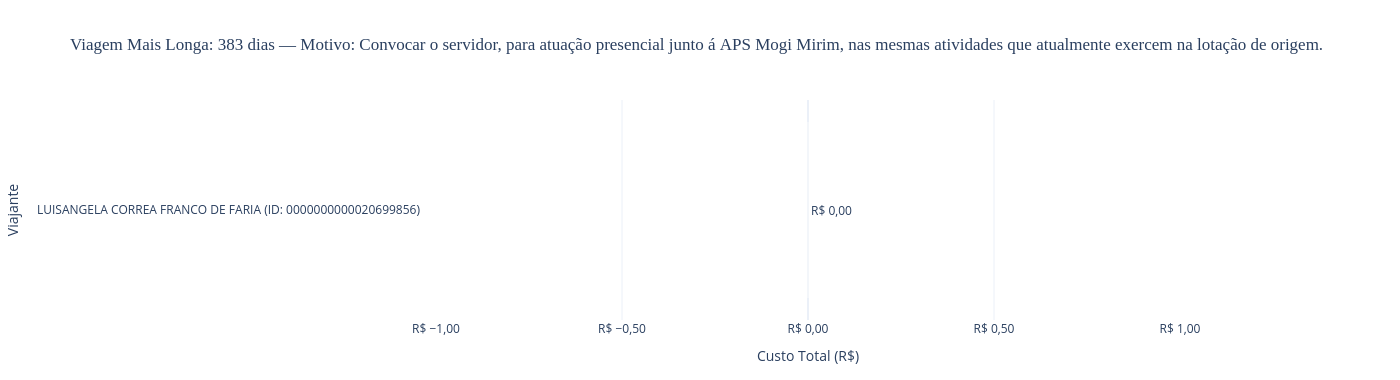

/tmp/ipykernel_114749/618038361.py:47: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig_p3.write_image('../graficos_png/3_detalhe_viagem_longa.png', engine='kaleido')
/tmp/ipykernel_114749/618038361.py:47: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig_p3.write_image('../graficos_png/3_detalhe_viagem_longa.png', engine='kaleido')


In [97]:
# --- GARANTE AS DUAS CASAS DECIMAIS CRAVADAS VIA PANDAS ---
df_p3['custo_formatado'] = df_p3['valor_total'].apply(lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

# Criando um rótulo identificador para o eixo
df_p3['identificador'] = df_p3['nome_viajante'] + " (ID: " + df_p3['id_viagem'].astype(str) + ")"

# 3. Geração do gráfico
fig_p3 = px.bar(
    df_p3, x='valor_total', y='identificador', orientation='h',
    title=f"Viagem Mais Longa: {df_p3['duracao_dias'].values[0]} dias — Motivo: {df_p3['motivo'].values[0]}",
    labels={'valor_total': 'Custo Total (R$)', 'identificador': 'Viajante'},
    color_discrete_sequence=['#ff7f0e']
)

# 5. Customização do layout com largura extra para o título longo
fig_p3.update_layout(
    template='plotly_white', 
    title_font_family='Arial Black', 
    width=1400,                          # <-- Largura ampliada para acomodar todo o título
    height=380,                          # <-- Ajuste leve na altura para equilibrar a nova largura
    margin=dict(l=320, r=220, t=100, b=60), # <-- 't=100' empurra o gráfico para baixo, liberando espaço para o título
    separators=',.',  
    
    # Ajustes no eixo Y
    yaxis=dict(
        ticklabelstandoff=15  
    ),
    
    # Ajustes no eixo X
    xaxis=dict(
        tickformat=',.2f',  
        tickprefix='R$ ',
        range=[0, df_p3['valor_total'].max() * 1.25] 
    )
)

# 6. Força o texto idêntico do Pandas na ponta da barra
fig_p3.update_traces(
    text=df_p3['custo_formatado'],  
    texttemplate='%{text}',         
    textposition='outside'        
)

fig_p3.show()

# --- ADICIONADO: Exportação do gráfico para imagem PNG ---
fig_p3.write_image('../graficos_png/3_detalhe_viagem_longa.png', engine='kaleido')

## 4. Qual o tipo de pagamento com maior valor médio?


/tmp/ipykernel_114749/2179344909.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,tipo_pagamento,valor_medio,custo_formatado
0,DIÁRIAS,2078.280299,"R$ 2.078,28"
1,PASSAGEM,1878.344393,"R$ 1.878,34"
2,Serviço correlato: seguro,447.514653,"R$ 447,51"
3,RESTITUIÇÃO,245.702610,"R$ 245,70"


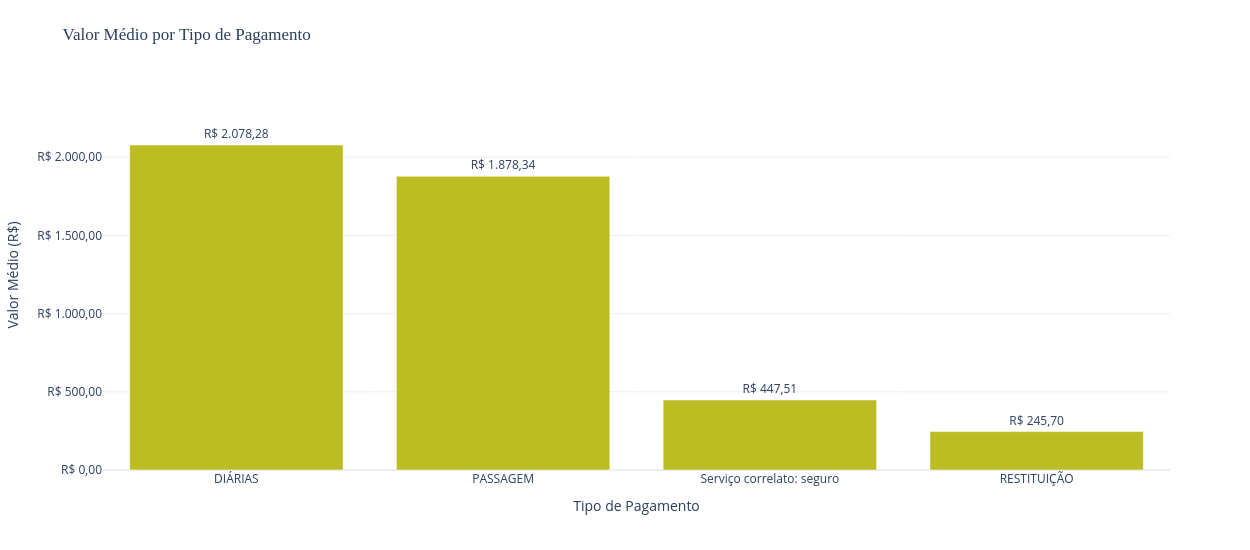

/tmp/ipykernel_114749/1837769924.py:53: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig_p4.write_image('../graficos_png/4_valor_medio_pagamento.png', engine='kaleido')
/tmp/ipykernel_114749/1837769924.py:53: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig_p4.write_image('../graficos_png/4_valor_medio_pagamento.png', engine='kaleido')


In [98]:
sql_p4 = """
SELECT tipo_pagamento, AVG(valor) AS valor_medio
FROM silver_pagamento
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC;
"""
df_p4 = consultar(sql_p4)

# --- GARANTE AS DUAS CASAS DECIMAIS CRAVADAS VIA PANDAS ---
df_p4['custo_formatado'] = df_p4['valor_medio'].apply(lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

display(df_p4)

# REMOVIDO o text_auto='.2f' para usar a nossa coluna formatada
fig_p4 = px.bar(
    df_p4, x='tipo_pagamento', y='valor_medio',
    title='Valor Médio por Tipo de Pagamento',
    labels={'valor_medio': 'Valor Médio (R$)', 'tipo_pagamento': 'Tipo de Pagamento'},
    color_discrete_sequence=['#bcbd22']
)

# 5. Customização do layout, largura ampliada e padrão monetário
fig_p4.update_layout(
    template='plotly_white', 
    title_font_family='Arial Black',
    width=1250,                     # Mantém o padrão largo do seu dashboard
    height=550,
    margin=dict(l=80, r=80, t=80, b=80),
    separators=',.',                # Padrão brasileiro de pontuação
    
    # Ajustes no eixo Y (valores financeiros)
    yaxis=dict(
        tickformat=',.2f',  
        tickprefix='R$ ',
        # Folga de 20% no teto para o texto do valor respirar livremente
        range=[0, df_p4['valor_medio'].max() * 1.20] 
    ),
    
    # Ajustes no eixo X
    xaxis=dict(
        tickangle=0                 # Nomes dos tipos de pagamento retos
    )
)

# 6. Força o texto idêntico do Pandas no topo das barras
fig_p4.update_traces(
    text=df_p4['custo_formatado'],  
    texttemplate='%{text}',         
    textposition='outside'
)

fig_p4.show()
fig_p4.write_image('../graficos_png/4_valor_medio_pagamento.png', engine='kaleido')

## 5. Qual o meio de transporte mais usado nos trechos?


/tmp/ipykernel_114749/2179344909.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,meio_transporte,quantidade_uso
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


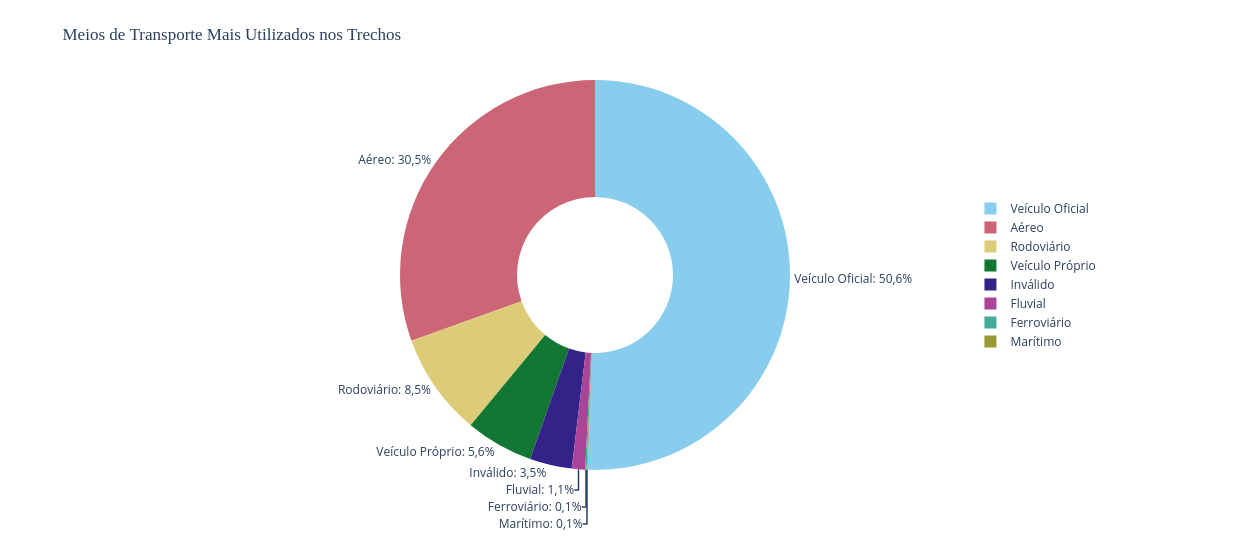

/tmp/ipykernel_114749/2788820568.py:45: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig_p5.write_image('../graficos_png/5_meio_transporte_mais_usado.png', engine='kaleido')
/tmp/ipykernel_114749/2788820568.py:45: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig_p5.write_image('../graficos_png/5_meio_transporte_mais_usado.png', engine='kaleido')


In [99]:
sql_p5 = """
SELECT meio_transporte, COUNT(*) AS quantidade_uso
FROM silver_trecho
WHERE meio_transporte IS NOT NULL AND meio_transporte <> ''
GROUP BY meio_transporte
ORDER BY quantidade_uso DESC;
"""
df_p5 = consultar(sql_p5)
display(df_p5)

fig_p5 = px.pie(
    df_p5, values='quantidade_uso', names='meio_transporte',
    title='Meios de Transporte Mais Utilizados nos Trechos',
    hole=0.4, 
    color_discrete_sequence=px.colors.qualitative.Safe
)

# Ajustado para forçar a porcentagem no padrão brasileiro (usando a vírgula definida no layout)
fig_p5.update_traces(
    textinfo='percent+label', 
    texttemplate='%{label}: %{percent:.1%}', # Ex: "Avião: 65,4%"
    textposition='outside'                    # Garante que o texto fique para fora se a fatia for pequena
)

# 5. Customização do layout, largura ampliada e separadores
fig_p5.update_layout(
    template='plotly_white', 
    title_font_family='Arial Black',
    width=1250,                               # Mantém o padrão largo dos outros gráficos
    height=550,
    margin=dict(l=100, r=100, t=80, b=80),    # Margens boas para os textos externos não sumirem
    separators=',.',                          # Troca o ponto por vírgula nas porcentagens do gráfico
    
    # Adiciona uma legenda limpa do lado direito
    legend=dict(
        orientation="v",
        yanchor="middle",
        y=0.5,
        xanchor="left",
        x=1.02
    )
)

fig_p5.show()
fig_p5.write_image('../graficos_png/5_meio_transporte_mais_usado.png', engine='kaleido')

## 6. Qual UF de destino aparece em mais trechos?


/tmp/ipykernel_114749/2179344909.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,uf_destino,quantidade_trechos
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603
5,Pará,40044
6,Rio Grande do Sul,38684
7,Mato Grosso do Sul,30516
8,Bahia,28375
9,Pernambuco,28372


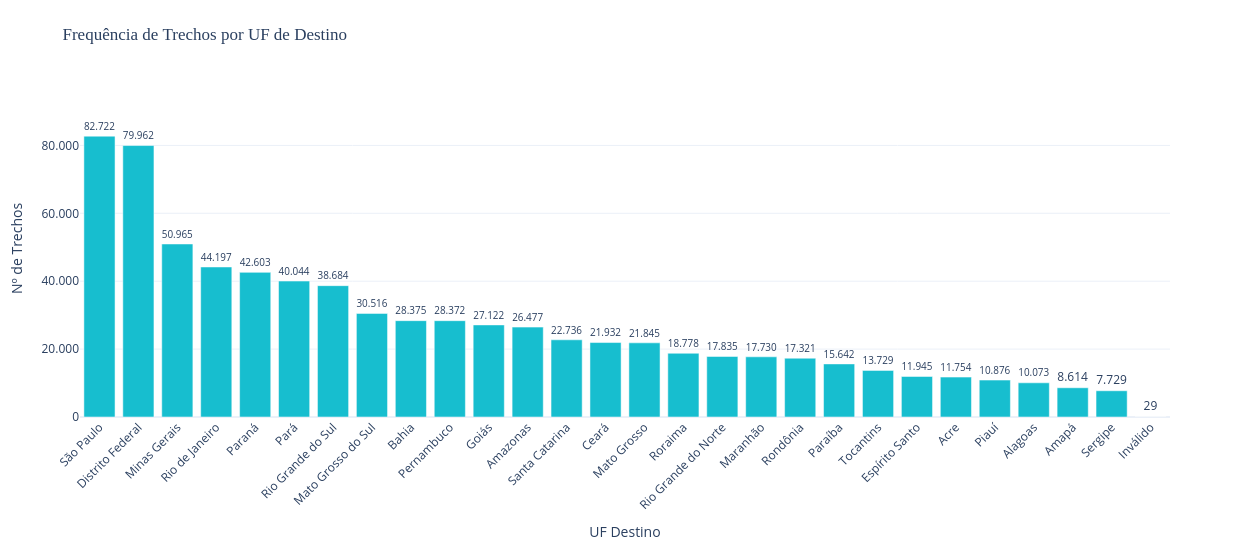

/tmp/ipykernel_114749/1897079888.py:52: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig_p6.write_image('../graficos_png/6_uf_destino_frequencia.png', engine='kaleido')
/tmp/ipykernel_114749/1897079888.py:52: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig_p6.write_image('../graficos_png/6_uf_destino_frequencia.png', engine='kaleido')


In [100]:
sql_p6 = f"""
SELECT {col_uf} AS uf_destino, COUNT(*) AS quantidade_trechos
FROM silver_trecho
WHERE {col_uf} IS NOT NULL AND {col_uf} <> ''
GROUP BY {col_uf}
ORDER BY quantidade_trechos DESC;
"""
df_p6 = consultar(sql_p6)
display(df_p6)

# Criamos uma coluna com a formatação inteira brasileira
df_p6['quantidade_formatada'] = df_p6['quantidade_trechos'].apply(lambda x: f"{x:,.0f}".replace(',', '.'))

fig_p6 = px.bar(
    df_p6, x='uf_destino', y='quantidade_trechos',
    title='Frequência de Trechos por UF de Destino',
    labels={'quantidade_trechos': 'Nº de Trechos', 'uf_destino': 'UF Destino'},
    color_discrete_sequence=['#17becf']
)

# 5. Customização do layout seguindo o padrão largo e com rotação no eixo X
fig_p6.update_layout(
    template='plotly_white', 
    title_font_family='Arial Black',
    width=1250,                     
    height=550,
    # Aumentamos a margem inferior (b=100) para o texto inclinado respirar sem cortar
    margin=dict(l=80, r=80, t=80, b=100),
    separators=',.',                
    
    # Ajustes no eixo Y (Contagem)
    yaxis=dict(
        tickformat=',.0f',          
        range=[0, df_p6['quantidade_trechos'].max() * 1.20] 
    ),
    
    # Ajustes no eixo X
    xaxis=dict(
        tickangle=-45,              # <-- Rotaciona as UFs em 45 graus para não embolar
        tickmode='array'            # Força o Plotly a mostrar todas as UFs sem pular nenhuma
    )
)

# 6. Força a exibição do texto numérico exato no topo de cada barra
fig_p6.update_traces(
    text=df_p6['quantidade_formatada'],  
    texttemplate='%{text}',         
    textposition='outside'
)

fig_p6.show()
fig_p6.write_image('../graficos_png/6_uf_destino_frequencia.png', engine='kaleido')

## 7. Qual órgão pagou mais no total?


/tmp/ipykernel_114749/2179344909.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,nome_orgao_superior,total_pago,custo_formatado
0,Ministério da Justiça e Segurança Pública,4.888311e+08,"R$ 488.831.110,61"
1,Ministério da Defesa,1.565498e+08,"R$ 156.549.767,91"
2,Ministério da Educação,1.118974e+08,"R$ 111.897.434,35"
3,Ministério do Meio Ambiente e Mudança do Clima,5.012304e+07,"R$ 50.123.043,80"
4,Ministério da Previdência Social,4.065949e+07,"R$ 40.659.494,63"


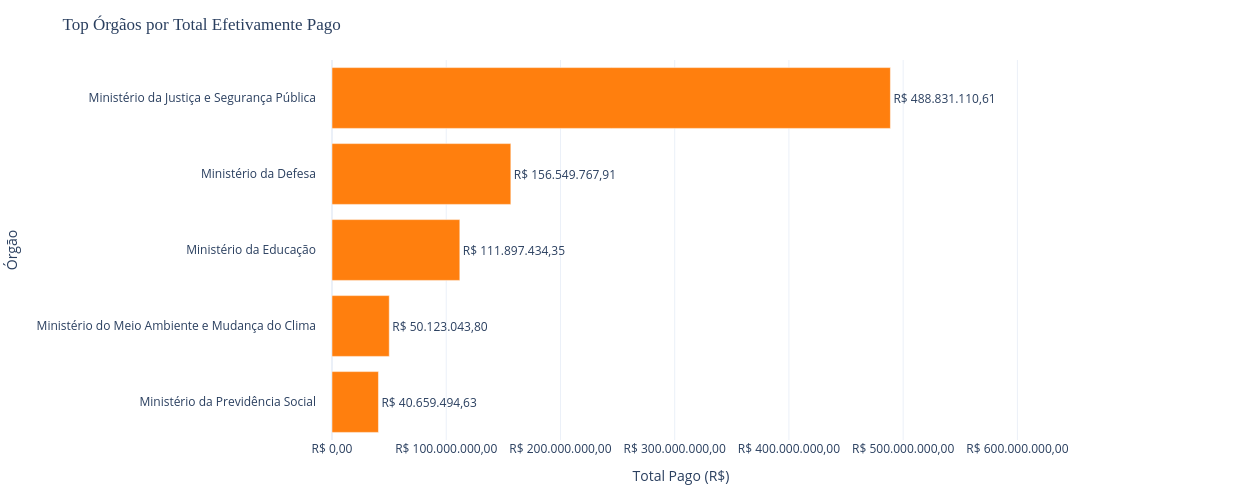

/tmp/ipykernel_114749/1895671471.py:55: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig_p7.write_image('../graficos_png/7_orgao_que_mais_pagou.png', engine='kaleido')
/tmp/ipykernel_114749/1895671471.py:55: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig_p7.write_image('../graficos_png/7_orgao_que_mais_pagou.png', engine='kaleido')


In [101]:
sql_p7 = """
SELECT v.nome_orgao_superior, SUM(p.valor) AS total_pago
FROM silver_pagamento p
INNER JOIN silver_viagem v ON p.id_viagem = v.id_viagem
GROUP BY v.nome_orgao_superior
ORDER BY total_pago DESC
LIMIT 5;
"""
df_p7 = consultar(sql_p7)

# --- GARANTE AS DUAS CASAS DECIMAIS CRAVADAS VIA PANDAS ---
df_p7['custo_formatado'] = df_p7['total_pago'].apply(lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

display(df_p7)

# REMOVIDO o text_auto='.2f' para usar a nossa coluna formatada
fig_p7 = px.bar(
    df_p7, x='total_pago', y='nome_orgao_superior', orientation='h',
    title='Top Órgãos por Total Efetivamente Pago',
    labels={'total_pago': 'Total Pago (R$)', 'nome_orgao_superior': 'Órgão'},
    color_discrete_sequence=['#ff7f0e']
)

# 5. Customização do layout, largura ampliada e padrão monetário
fig_p7.update_layout(
    template='plotly_white', 
    title_font_family='Arial Black', 
    width=1250,                             # Mantém o padrão largo dos outros horizontais
    height=500,
    margin=dict(l=320, r=220, t=60, b=60),  # Margem l=320 para os órgãos e r=220 para os centavos
    separators=',.',                        # Garante vírgula nos centavos
    
    # Ajustes no eixo Y (Nomes dos órgãos)
    yaxis=dict(
        categoryorder='total ascending',
        ticklabelstandoff=15  
    ),
    
    # Ajustes no eixo X (Valores)
    xaxis=dict(
        tickformat=',.2f',  
        tickprefix='R$ ',
        range=[0, df_p7['total_pago'].max() * 1.25] # 25% de folga para os números externos respirarem
    )
)

# 6. Força o texto idêntico do Pandas na ponta da barra
fig_p7.update_traces(
    text=df_p7['custo_formatado'],  
    texttemplate='%{text}',         
    textposition='outside'        
)

fig_p7.show()
fig_p7.write_image('../graficos_png/7_orgao_que_mais_pagou.png', engine='kaleido')

In [102]:
conexao.close()
print('Análise das 7 questões finalizada e salva com sucesso!')


Análise das 7 questões finalizada e salva com sucesso!
